# Paper 03 — De Magalhães, Hangartner, Hirvonen, Meriläinen, Ruiz & Tukiainen: *When Can We Trust RDD Estimates from Close Elections?*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/afrtrivi1120/causal-inference-papers-explainer/blob/master/papers/rdd/03-demagalhaes-et-al-rdd-close-elections/simulation.ipynb)

See this folder's `README.md` for the 12-section explainer. This notebook is its runnable companion.

**What this simulation shows.** In a sharp RDD where `E[Y | X]` has real curvature near the cutoff, two `rdrobust` recipes diverge:

- `p = 1`, **MSE-optimal** bandwidth, **Conventional** inference — the off-the-shelf default. Bias is left in the point estimate, and the CI does not adjust for it.
- `p = 1`, **CER-optimal** bandwidth, **Robust (bias-corrected)** inference — the paper's recommended default when curvature is a concern. Smaller bandwidth + bias-corrected inference.

This is a single-draw illustration. The paper's coverage claim is in expectation across many draws; here we look at one draw and ask whether each CI covers the true `tau = 0.5`. The full coverage tables in the paper do this thousands of times.


## Setup

In [1]:
if (!requireNamespace('rdrobust', quietly = TRUE)) install.packages('rdrobust', quiet = TRUE)

suppressPackageStartupMessages({
  library(tidyverse)
  library(rdrobust)
})
set.seed(20260421)

cat(sprintf('R          %s\n', paste(R.version$major, R.version$minor, sep = '.')))
cat(sprintf('tidyverse  %s\n', packageVersion('tidyverse')))
cat(sprintf('rdrobust   %s\n', packageVersion('rdrobust')))


R          4.5.3


tidyverse  2.0.0


rdrobust   3.0.0


## Parameters and DGP

`mu(X)` has strong cubic curvature near the cutoff — exactly the case where MSE-optimal bandwidths leave visible bias.

In [2]:
N        <- 2000      # one draw
TAU_TRUE <- 0.5       # true sharp RDD treatment effect at the cutoff
SIGMA    <- 0.3       # noise SD

mu <- function(x) 0.5 + 3 * x + 50 * x^2 + 80 * x^3

X <- runif(N, -1, 1)
D <- as.integer(X >= 0)
Y <- mu(X) + TAU_TRUE * D + rnorm(N, 0, SIGMA)


## Two specifications, side by side

In [3]:
fit_mse <- suppressWarnings(rdrobust(y = Y, x = X, c = 0, p = 1, bwselect = 'mserd'))
fit_cer <- suppressWarnings(rdrobust(y = Y, x = X, c = 0, p = 1, bwselect = 'cerrd'))

# Label-safety: rdrobust returns rows named Conventional / Bias-Corrected / Robust.
stopifnot(
  'Conventional' %in% rownames(fit_mse$coef),
  'Robust'       %in% rownames(fit_cer$coef)
)

row_for <- function(fit, label) {
  list(estimate = unname(fit$coef[label, 1]),
       ci_low   = unname(fit$ci  [label, 1]),
       ci_high  = unname(fit$ci  [label, 2]),
       h        = unname(fit$bws['h', 1]))
}
mse <- row_for(fit_mse, 'Conventional')
cer <- row_for(fit_cer, 'Robust')

results <- tibble(
  specification = c('p=1, MSE-opt, Conventional', 'p=1, CER-opt, Robust (BC)'),
  estimate      = c(mse$estimate, cer$estimate),
  ci_low        = c(mse$ci_low,   cer$ci_low),
  ci_high       = c(mse$ci_high,  cer$ci_high),
  bandwidth_h   = c(mse$h,        cer$h),
  covers_truth  = c(mse$ci_low <= TAU_TRUE & TAU_TRUE <= mse$ci_high,
                    cer$ci_low <= TAU_TRUE & TAU_TRUE <= cer$ci_high)
)
results


specification,estimate,ci_low,ci_high,bandwidth_h,covers_truth
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
"p=1, MSE-opt, Conventional",0.4941883,0.3391160,0.6492605,0.1043953,TRUE
"p=1, CER-opt, Robust (BC)",0.4772929,0.2958466,0.6587391,0.0713887,TRUE


## Diagnostic plot

The one simulated draw with the true cubic conditional mean overlaid, the cutoff dashed, and the two bandwidth windows shaded — the CER-optimal window is narrower than the MSE-optimal one, trading variance for less bias.

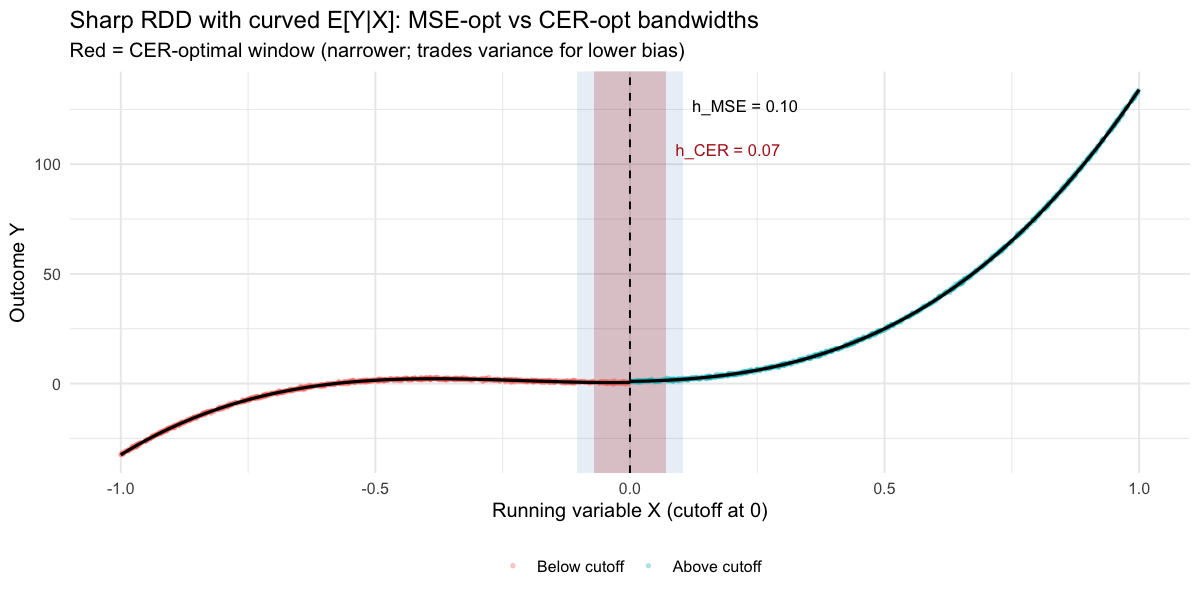

In [4]:
grid <- tibble(X = seq(-1, 1, length.out = 400)) |>
  mutate(mu = mu(X) + TAU_TRUE * (X >= 0))

options(repr.plot.width = 10, repr.plot.height = 5)

ggplot(tibble(X, Y, side = factor(D, labels = c('Below cutoff', 'Above cutoff'))),
       aes(X, Y)) +
  annotate('rect', xmin = -mse$h, xmax = mse$h, ymin = -Inf, ymax = Inf,
           alpha = 0.12, fill = 'steelblue') +
  annotate('rect', xmin = -cer$h, xmax = cer$h, ymin = -Inf, ymax = Inf,
           alpha = 0.22, fill = 'firebrick') +
  geom_point(aes(colour = side), alpha = 0.30, size = 0.8) +
  geom_line(data = grid, aes(X, mu), linewidth = 0.9, colour = 'black') +
  geom_vline(xintercept = 0, linetype = 'dashed') +
  annotate('text', x = mse$h, y =  max(Y) * 0.95,
           label = sprintf('  h_MSE = %.2f', mse$h), hjust = 0, size = 3.5) +
  annotate('text', x = cer$h, y =  max(Y) * 0.80,
           label = sprintf('  h_CER = %.2f', cer$h), hjust = 0, size = 3.5,
           colour = 'firebrick') +
  labs(title    = 'Sharp RDD with curved E[Y|X]: MSE-opt vs CER-opt bandwidths',
       subtitle = 'Red = CER-optimal window (narrower; trades variance for lower bias)',
       x = 'Running variable X (cutoff at 0)', y = 'Outcome Y',
       colour = NULL) +
  theme_minimal(base_size = 12) +
  theme(legend.position = 'bottom')


## Punchline

At this seed both CIs cover the truth (`tau = 0.5`). What the single draw makes visible is the **mechanism** the paper warns about, not the coverage claim itself:

- **MSE-optimal bandwidth** (`h_MSE`) is wider, so more of the curved cubic sits inside the local-linear window. That leaves bias in the conventional point estimate; conventional inference does not adjust for it.
- **CER-optimal bandwidth** (`h_CER`) is *narrower* — the visible red shaded window — so less curvature distorts the fit, and the robust CI corrects for the residual bias.

The paper's coverage claim is a property of the sampling distribution: across thousands of draws under realistic curvature, MSE-opt + Conventional empirically covers around 92–93% (vs. 95% nominal), while CER-opt + Robust gets close to nominal. One draw cannot demonstrate that — the De Magalhães et al. Monte Carlo can. What this notebook shows is *why* it happens: bandwidth choice changes how much curvature the linear fit has to absorb, and inference flavor decides whether the resulting bias is reflected in the CI.

To see the coverage claim yourself, open the notebook on Colab and bump `SIGMA`, sharpen the cubic in `mu(X)`, or shrink `N` — across many seeds the MSE-opt + Conventional CI misses more often than 5%.
